<a href="https://colab.research.google.com/github/HindAlamrii/medical-data-feature-engineering-pipeline/blob/main/Feature_Engineering_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
import pandas as pd

drive.mount('/content/drive')

file_path = '/content/drive/MyDrive/FE/FE1.csv'
df = pd.read_csv(file_path)

print('columns :', df.shape[1])
print('rows :', df.shape[0])
print(df.info())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/tmp/ipykernel_3091/264006445.py:7: DtypeWarning: Columns (12,13,14,16,18,20,21,22,23,25,26,29,30,32,34,35,36,37,38,45,46,47,48,49,50,53,56,59,60,61,62,63,64,65,67,68,69,70,71,72,73,74,79,81,82,83,84,85,86,87,88,89,90,92,96,97,98,99,100,101,102,103,105,107) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


columns : 108
rows : 929107
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 929107 entries, 0 to 929106
Columns: 108 entries, RESEARCH_ID to 'Cystatin C'.1
dtypes: float64(29), object(79)
memory usage: 765.6+ MB
None


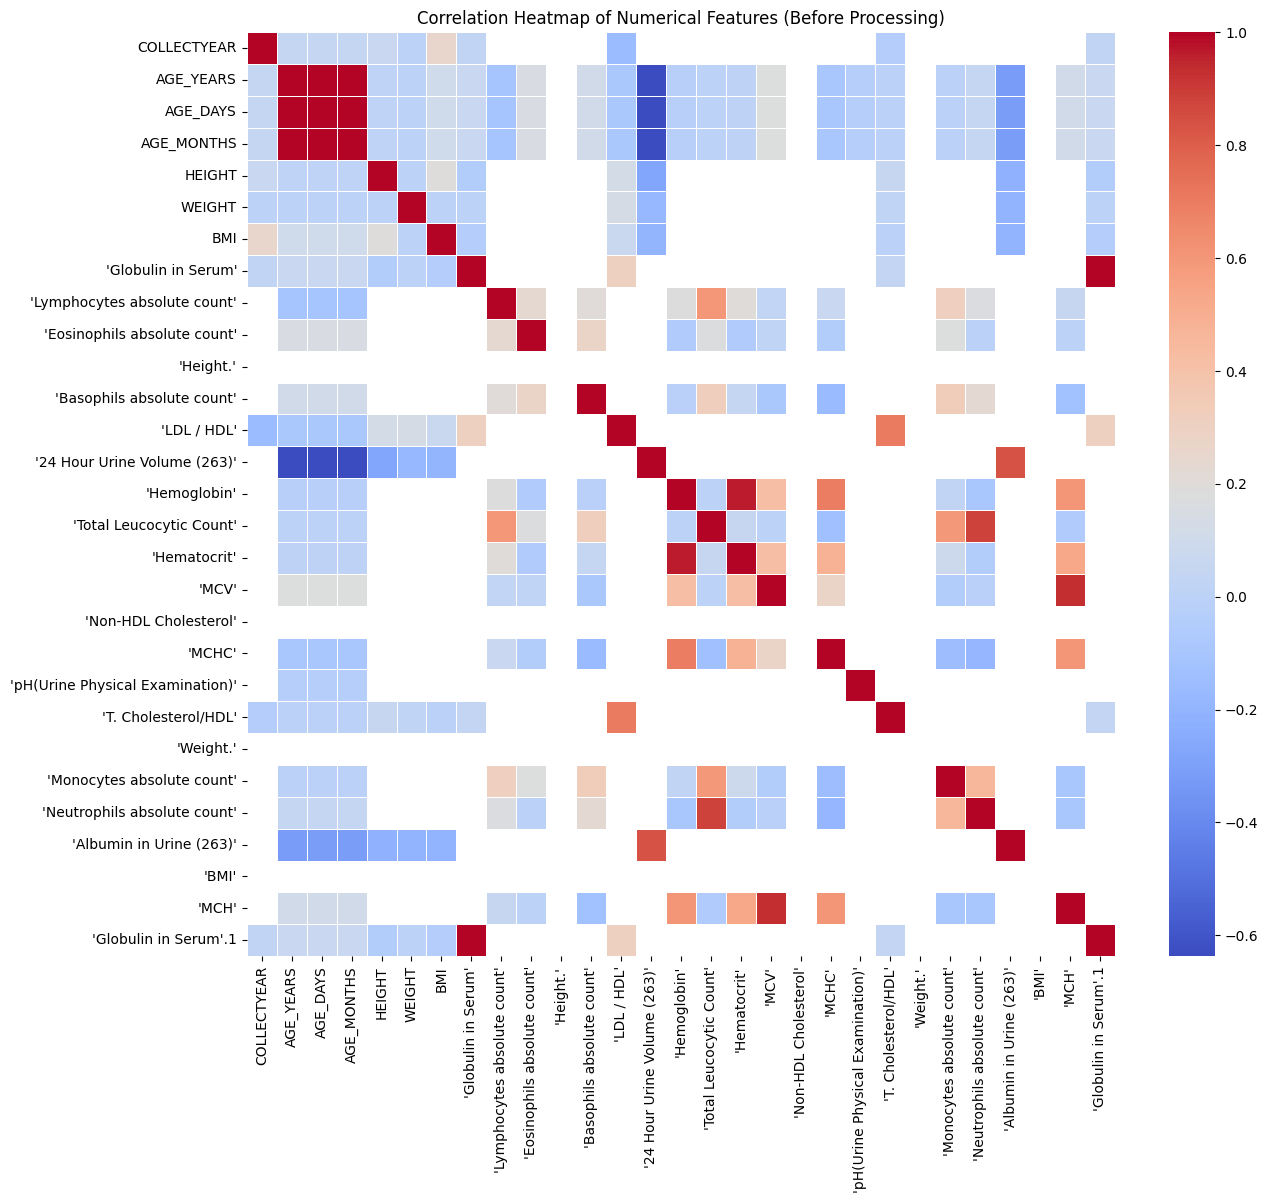

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# berfore preprocessing
numeric_cols_before = df.select_dtypes(include=['float64', 'int64']).columns

plt.figure(figsize=(14,12))
sns.heatmap(df[numeric_cols_before].corr(), cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap of Numerical Features (Before Processing)")
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.model_selection import train_test_split

In [ ]:
df.columns = df.columns.str.strip() \
                       .str.replace("'", "") \
                       .str.replace('"', '') \
                       .str.replace("(", "") \
                       .str.replace(")", "") \
                       .str.replace(" ", "_") \
                       .str.replace("/", "_") \
                       .str.replace(".", "")

In [ ]:
df = df.loc[:, ~df.columns.duplicated()]
df = df.drop(columns=['RESEARCH_ID', 'SAMPLE_ID'], errors='ignore')
df = df.drop(columns=['AGE_MONTHS', 'AGE_DAYS'], errors='ignore')

In [ ]:
df['REGN_DATE'] = pd.to_datetime(df['REGN_DATE'], errors='coerce')
df['year'] = df['REGN_DATE'].dt.year
df['month'] = df['REGN_DATE'].dt.month
df['dayofweek'] = df['REGN_DATE'].dt.dayofweek

In [ ]:
target = 'LDL_Cholesterol'
y = pd.to_numeric(df[target], errors='coerce')

In [ ]:
# Ensure the target column is fully numeric in 'df' before operations
df['LDL_Cholesterol'] = pd.to_numeric(df['LDL_Cholesterol'], errors='coerce')

# Check the maximum value, ignoring NaNs
print(f"The maximum value in LDL: {df['LDL_Cholesterol'].max()}")

# Show the top 10 highest values to identify outliers, ignoring NaNs
print(df['LDL_Cholesterol'].sort_values(ascending=False).head(10))

The maximum value in LDL: 1e+100
185139    1.000000e+100
725119     5.340000e+02
823904     4.940000e+02
728348     4.840000e+02
724871     3.910000e+02
795591     3.870000e+02
765175     3.830000e+02
686956     3.820000e+02
904983     3.770000e+02
751425     3.770000e+02
Name: LDL_Cholesterol, dtype: float64


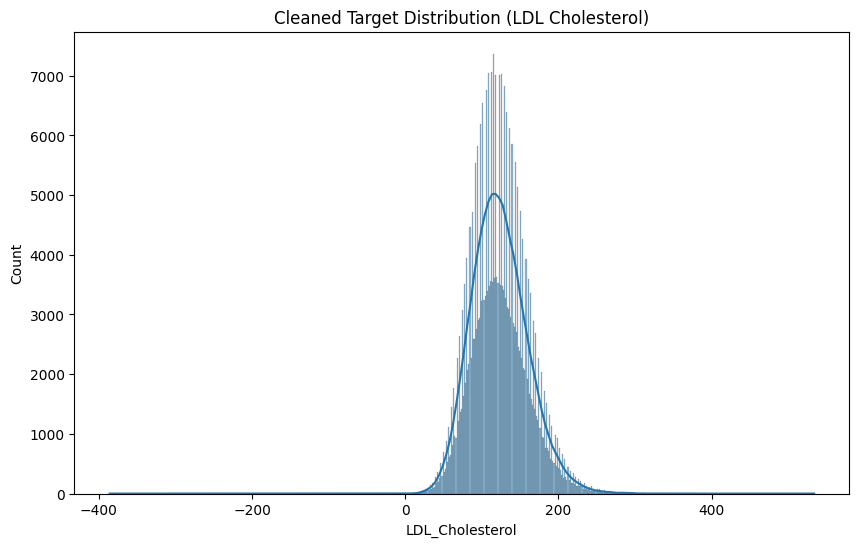

In [ ]:
# realistic medical values (e.g., less than 600)
df_clean = df[df['LDL_Cholesterol'] < 600].copy()

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.histplot(df_clean['LDL_Cholesterol'], kde=True)
plt.title('Cleaned Target Distribution (LDL Cholesterol)')
plt.show()

In [ ]:
# Filter out negative values if they exist
df_clean = df_clean[df_clean['LDL_Cholesterol'] >= 0]

In [ ]:
mask = y.notna()
X = df.loc[mask, df.columns != target]
y = y[mask]

# train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training records: {X_train.shape[0]}, Testing records: {X_test.shape[0]}")

Training records: 253784, Testing records: 63446


In [ ]:
cols_to_drop = ['CITY_NAME']
X_train = X_train.drop(columns=cols_to_drop, errors='ignore')
X_test = X_test.drop(columns=cols_to_drop, errors='ignore')

In [ ]:
import numpy as np

numeric_features = X_train.select_dtypes(include=['int64','float64']).columns.tolist()
categorical_features = X_train.select_dtypes(include=['object']).columns.tolist()

In [ ]:
def reduce_categories(df, col, top_k=10):
    top = df[col].value_counts().nlargest(top_k).index
    df[col] = df[col].where(df[col].isin(top), 'Other')

for col in categorical_features:
    reduce_categories(X_train, col)
    reduce_categories(X_test, col)

In [ ]:
for col in categorical_features:
    X_train[col] = X_train[col].astype(str)
    X_test[col] = X_test[col].astype(str)

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', max_categories=10))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

pipeline = Pipeline([
    ('preprocessor', preprocessor)
])

In [ ]:
X_train_processed = pipeline.fit_transform(X_train)
X_test_processed = pipeline.transform(X_test)

print("After preprocessing:")
print(X_train_processed.shape)

/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['Lymphocytes_absolute_count' 'Eosinophils_absolute_count' 'Height'
 'Basophils_absolute_count' '24_Hour_Urine_Volume_263' 'Hemoglobin'
 'Total_Leucocytic_Count' 'Hematocrit' 'MCV' 'Non-HDL_Cholesterol' 'MCHC'
 'pHUrine_Physical_Examination' 'Weight' 'Monocytes_absolute_count'
 'Neutrophils_absolute_count' 'Albumin_in_Urine_263' 'MCH']. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['Lymphocytes_absolute_count' 'Eosinophils_absolute_count' 'Height'
 'Basophils_absolute_count' '24_Hour_Urine_Volume_263' 'Hemoglobin'
 'Total_Leucocytic_Count' 'Hematocrit' 'MCV' 'Non-HDL_Cholesterol' 'MCHC'
 'pHUrine_Physical_Examination' 'Weight' 'Monocytes_absolute_count'
 'Neutrophils_absolute_count' 

After preprocessing:
(253784, 501)


In [ ]:
from sklearn.feature_selection import SelectKBest, f_regression

selector = SelectKBest(score_func=f_regression, k=70)

X_train_selected = selector.fit_transform(X_train_processed, y_train)
X_test_selected = selector.transform(X_test_processed)

print("Final shape:")
print(X_train_selected.shape)

Final shape:
(253784, 70)


/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:381: RuntimeWarning: invalid value encountered in sqrt
  X_norms = np.sqrt(row_norms(X.T, squared=True) - n_samples * X_means**2)


In [ ]:
# Get the names for numeric features, prefixed by 'num__' as per ColumnTransformer's convention
numeric_output_names = [f"num__{col}" for col in numeric_features]

# Get the OneHotEncoder component from the preprocessor's categorical pipeline
categorical_ohe = pipeline.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot']

categorical_output_names = [f"cat__{name}" for name in categorical_ohe.get_feature_names_out(categorical_features)]

# Combine all feature names into a single list before feature selection
preprocessed_feature_names = numeric_output_names + categorical_output_names

# Get the mask of selected features from the selector (SelectKBest)
selected_mask = selector.get_support()

# Filter the preprocessed feature names using the selector's mask
selected_numeric_features = [feature_name for feature_name, selected in zip(preprocessed_feature_names, selected_mask) if selected]

print(f"Length of selected_numeric_features after re-generation: {len(selected_numeric_features)}")
print(f"First 5 selected features: {selected_numeric_features[:5]}")

Length of selected_numeric_features after re-generation: 70
First 5 selected features: ['num__COLLECTYEAR', 'num__HEIGHT', 'num__WEIGHT', 'num__BMI', 'num__Globulin_in_Serum']


In [ ]:
X_train_selected_dense = X_train_selected.toarray()
X_test_selected_dense = X_test_selected.toarray()

print(f"Shape of X_train_selected_dense before DataFrame creation: {X_train_selected_dense.shape}")
print(f"Length of selected_numeric_features before DataFrame creation: {len(selected_numeric_features)}")

X_train_df = pd.DataFrame(X_train_selected_dense, columns=selected_numeric_features)
X_test_df = pd.DataFrame(X_test_selected_dense, columns=selected_numeric_features)

# target column
X_train_df[target] = y_train.reset_index(drop=True)
X_test_df[target] = y_test.reset_index(drop=True)

print("Training shape:", X_train_df.shape)
print("Testing shape:", X_test_df.shape)

Shape of X_train_selected_dense before DataFrame creation: (253784, 70)
Length of selected_numeric_features before DataFrame creation: 70
Training shape: (253784, 71)
Testing shape: (63446, 71)


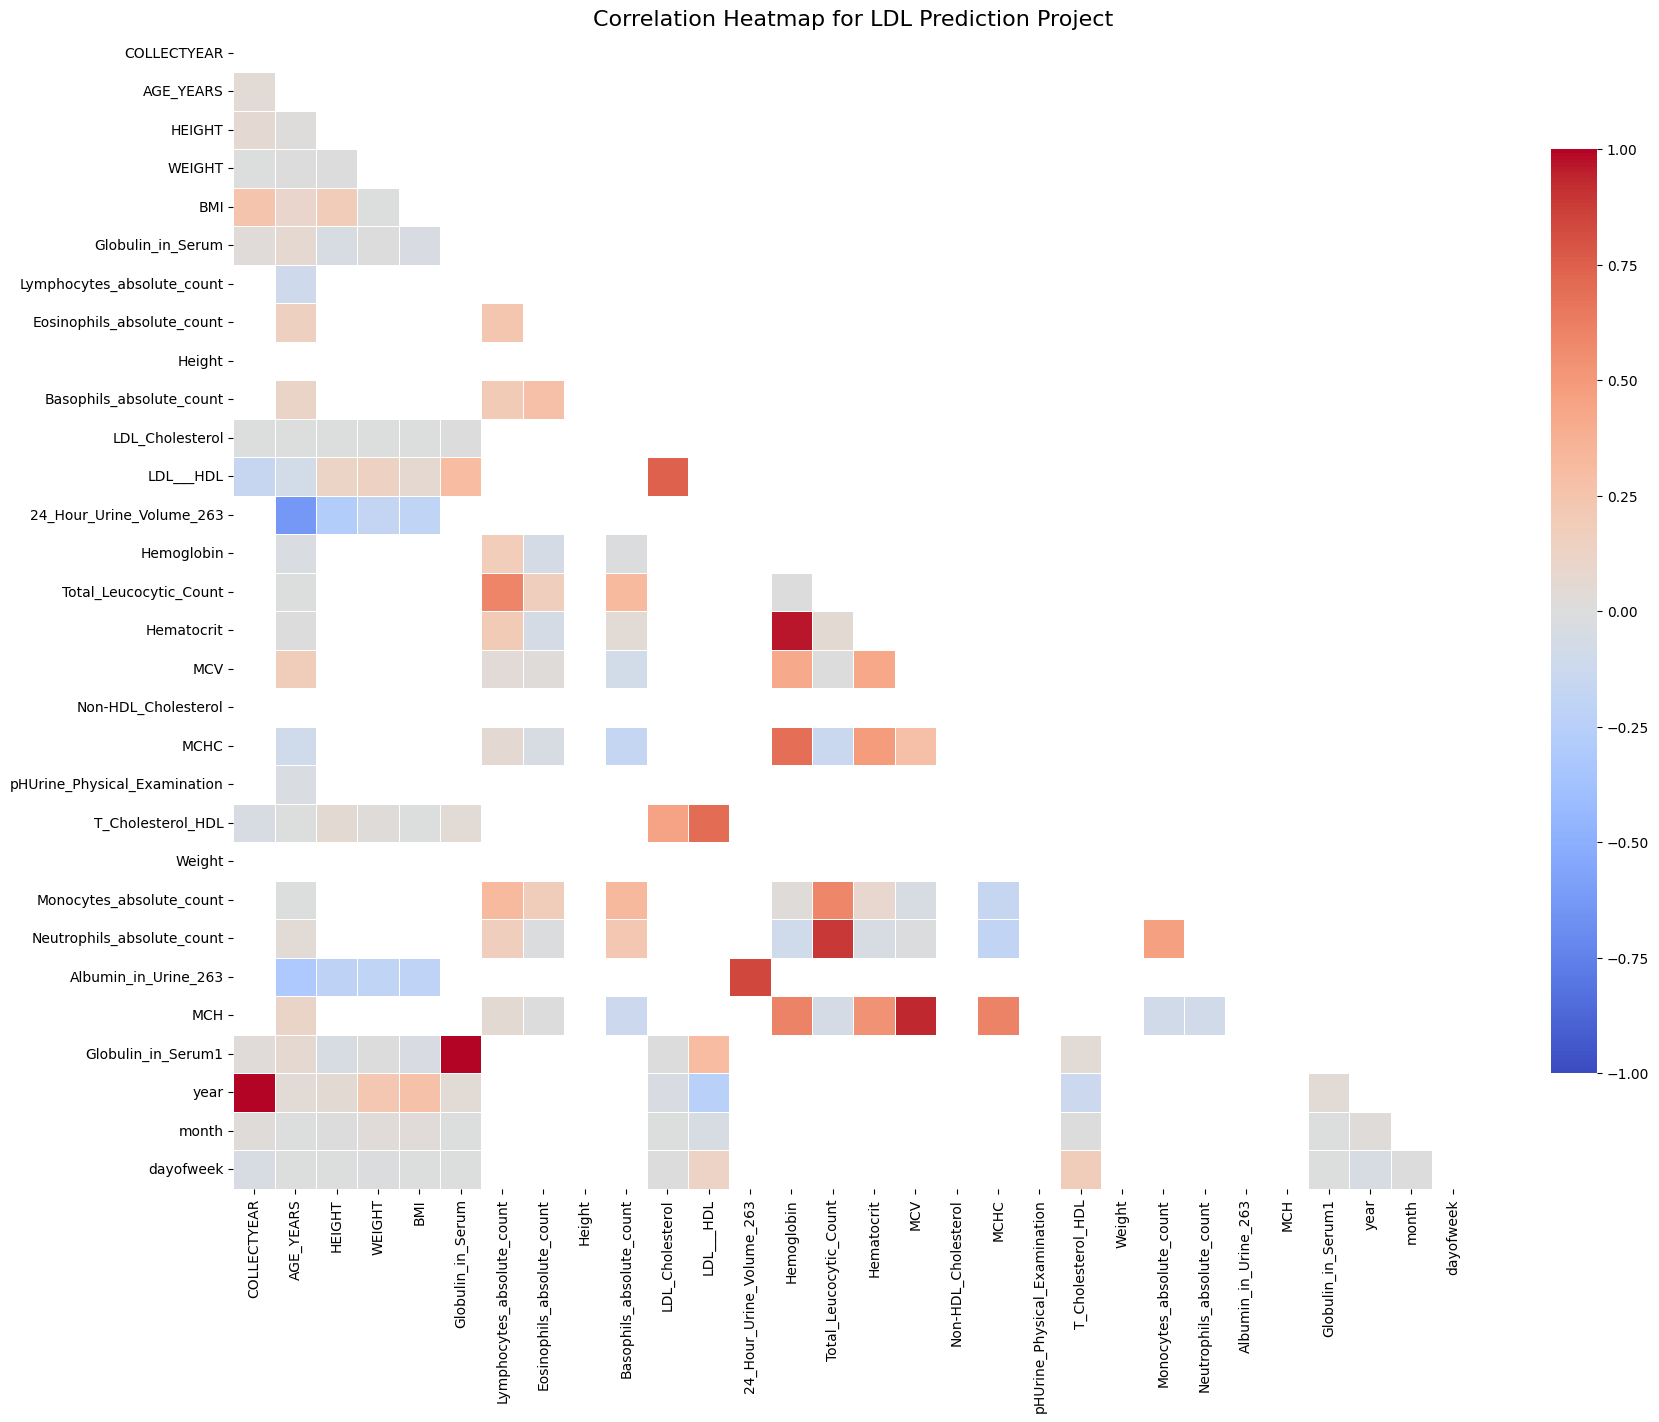

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# only use numerical columns
corr_matrix = df.select_dtypes(include=[np.number]).corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(20, 15))

sns.heatmap(corr_matrix,
            mask=mask,
            annot=False,
            fmt=".2f",
            cmap='coolwarm',     # Red for positive, Blue for negative
            vmin=-1, vmax=1,      # Ensure the scale is consistent
            center=0,
            linewidths=0.5,
            cbar_kws={"shrink": .8})

plt.title('Correlation Heatmap for LDL Prediction Project', fontsize=16)
plt.show()

In [ ]:
print("Correlation of features with LDL_Cholesterol:")
print(corr_matrix['LDL_Cholesterol'].sort_values(ascending=False))

Correlation of features with LDL_Cholesterol:
LDL___HDL                       0.746052
T_Cholesterol_HDL               0.451040
dayofweek                       0.006045
Globulin_in_Serum               0.000928
Globulin_in_Serum1              0.000928
LDL_Cholesterol                 0.000000
AGE_YEARS                      -0.000350
month                          -0.000827
WEIGHT                         -0.000918
COLLECTYEAR                    -0.001926
BMI                            -0.003958
HEIGHT                         -0.004452
year                           -0.036703
Lymphocytes_absolute_count           NaN
Eosinophils_absolute_count           NaN
Height                               NaN
Basophils_absolute_count             NaN
24_Hour_Urine_Volume_263             NaN
Hemoglobin                           NaN
Total_Leucocytic_Count               NaN
Hematocrit                           NaN
MCV                                  NaN
Non-HDL_Cholesterol                  NaN
MCHC       

In [ ]:
import pandas as pd

# --- Original dataset info ---
original_rows = df.shape[0]
original_cols = df.shape[1]
original_nulls = df.isnull().sum().sum()
original_numeric_cols = df.select_dtypes(include='number').shape[1]

processed_rows = X_train_df.shape[0] + X_test_df.shape[0]

processed_cols = len(selected_numeric_features) # 70 features
# After preprocessing (scaling and one-hot encoding), all features are numerical.
processed_numeric_cols = processed_cols
processed_text_cols = 0 # No text columns remain after one-hot encoding

# Calculate nulls in features only
processed_nulls = X_train_df.drop(columns=[target]).isnull().sum().sum() + X_test_df.drop(columns=[target]).isnull().sum().sum()

# --- Other info ---
duplicates_removed = df.duplicated().sum()
# Calculate deleted columns: Original columns (106) - (processed features (70) + 1 for target)
deleted_columns = original_cols - (processed_cols + 1)

added_columns = 0
training_records = X_train.shape[0]
testing_records = X_test.shape[0]

# Create a summary DataFrame
summary_df = pd.DataFrame({
    "Description": [
        "Number of rows (Original dataset)",
        "Number of duplicate rows (After process)",
        "Number of rows (After All processes)",
        "Number of columns (Original dataset)",
        "Number of columns (After process)",
        "Total number of null values (Original dataset)",
        "Total number of null values (After process)",
        "Number of numerical columns (Before process)",
        "Number of numerical columns (After process)",
        "Number of text columns (After process)",
        "Number of deleted columns (After process)",
        "Number of Added columns (After process)",
        "Number of training records",
        "Number of testing records"
    ],
    "Result": [
        original_rows,
        duplicates_removed,
        processed_rows,
        original_cols,
        processed_cols,
        original_nulls,
        processed_nulls,
        original_numeric_cols,
        processed_numeric_cols,
        processed_text_cols,
        deleted_columns,
        added_columns,
        training_records,
        testing_records
    ]
})

# Display summary table
print(summary_df)


                                       Description    Result
0                Number of rows (Original dataset)    929107
1         Number of duplicate rows (After process)     38819
2             Number of rows (After All processes)    317230
3             Number of columns (Original dataset)       106
4                Number of columns (After process)        70
5   Total number of null values (Original dataset)  76850767
6      Total number of null values (After process)         0
7     Number of numerical columns (Before process)        30
8      Number of numerical columns (After process)        70
9           Number of text columns (After process)         0
10       Number of deleted columns (After process)        35
11         Number of Added columns (After process)         0
12                      Number of training records    253784
13                       Number of testing records     63446
